# Chopin Op. 30 No. 2 HMM/DTW Debug Run

This notebook trains one HMM for `Chopin_Op030No2` from a single reference recording and 70% of that piece's recordings, then evaluates three held-out recordings. The final plot compares mean absolute alignment error in seconds for Viterbi, streaming DTW, and HMM-influenced streaming DTW against an offline `librosa.sequence.dtw` baseline.

In [ ]:
from pathlib import Path
import numpy as np

PIECE_ID = "Chopin_Op030No2"
DATA_DIR = Path("data/wav_22050_mono") / PIECE_ID
TRAIN_FRACTION = 0.70
TEST_RECORDING_COUNT = 3

recording_paths = sorted(DATA_DIR.glob("*.wav"))
reference_path = recording_paths[0]

rng = np.random.default_rng(207)
query_pool = np.array(recording_paths[1:], dtype=object)
shuffled_pool = query_pool[rng.permutation(len(query_pool))]
train_count = int(np.ceil(TRAIN_FRACTION * len(recording_paths))) - 1
train_paths = sorted(shuffled_pool[:train_count])
heldout_paths = sorted(shuffled_pool[train_count:])
test_paths = heldout_paths[:TEST_RECORDING_COUNT]

print(f"reference: {reference_path.name}")
print(f"total recordings: {len(recording_paths)}")
print(f"training recordings: {1 + len(train_paths)} including the reference ({(1 + len(train_paths)) / len(recording_paths):.1%})")
print(f"held-out recordings: {len(heldout_paths)}")
print("test queries:")
for path in test_paths:
    print(f"  {path.name}")

## Train One Debug HMM

In [ ]:
import importlib
import IterativeTrainHMM
importlib.reload(IterativeTrainHMM)

A, Pi, Means, Covars = IterativeTrainHMM.Exec_IterativeTrainHMM(
    str(reference_path),
    [str(path) for path in train_paths],
)

print(f"transition matrix: {A.shape}")
print(f"initial distribution: {Pi.shape}")
print(f"emission states: {len(Means)}")
print(f"feature dim: {Means[0].shape[0]}")

## Load Reference Features

In [ ]:
import librosa
import Constants

reference_audio, sample_rate = librosa.load(reference_path, sr=Constants.DEFAULT_SAMPLE_RATE)
reference_chroma = librosa.feature.chroma_stft(
    y=reference_audio,
    sr=sample_rate,
    hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
)

print(f"reference chroma: {reference_chroma.shape}")

## Offline DTW Helpers

In [ ]:
def path_to_query_reference_series(path, query_frame_count):
    series = np.full(query_frame_count, np.nan)
    for query_index in range(query_frame_count):
        matching_ref_frames = path[path[:, 1] == query_index, 0]
        if len(matching_ref_frames):
            series[query_index] = np.median(matching_ref_frames)

    valid = np.flatnonzero(~np.isnan(series))
    if len(valid) == 0:
        raise ValueError("DTW path did not cover any query frames")

    missing = np.flatnonzero(np.isnan(series))
    if len(missing):
        series[missing] = np.interp(missing, valid, series[valid])
    return series


def offline_dtw_reference_by_query(reference_chroma, query_chroma):
    _, offline_warping_path = librosa.sequence.dtw(
        X=reference_chroma,
        Y=query_chroma,
        backtrack=True,
    )
    offline_path = offline_warping_path[::-1]
    return path_to_query_reference_series(offline_path, query_chroma.shape[1])

## Evaluate Three Held-Out Recordings

In [234]:
import importlib
from scipy.special import logsumexp
import HMMOLTW

importlib.reload(HMMOLTW)

SEARCH_HALF_WIDTH = 250
VITERBI_GLOBAL_HALF_WIDTH = 100
HMM_STREAMING_DTW_WEIGHT = 0.6


def run_streaming_dtw(reference_chroma, query_chroma, search_half_width=SEARCH_HALF_WIDTH):
    streaming_dtw_state = HMMOLTW.InitializeStreamingDTW(reference_chroma.shape[1])
    dummy_viterbi_log_probs = np.zeros(reference_chroma.shape[1])

    estimates = []
    for query_index in range(query_chroma.shape[1]):
        streaming_dtw_state = HMMOLTW.StepStreamingDTW(
            streaming_dtw_state,
            reference_chroma,
            query_chroma[:, query_index],
            dummy_viterbi_log_probs,
            search_half_width,
            HMMWeight=0.0,
        )
        estimates.append(streaming_dtw_state.CurrentReferenceEstimate)
    return np.array(estimates)


def global_constraint_center(query_index, query_frame_count, state_count):
    if query_frame_count <= 1:
        return 0
    progress = query_index / (query_frame_count - 1)
    return int(round(progress * (state_count - 1)))


def step_viterbi_global_constraint(running_state, hmm, observation, center, half_width):
    state_count = hmm.StateCount
    window_start = max(0, center - half_width)
    window_end = min(state_count, center + half_width + 1)
    active_states = np.arange(window_start, window_end)

    previous_active_states = np.flatnonzero(np.isfinite(running_state.NormalizedLogProbabilities))
    if len(previous_active_states) == 0:
        previous_active_states = np.array([max(0, min(center, state_count - 1))])

    log_emissions = np.array([
        HMMOLTW.ComputeLogGaussianEmission(
            observation,
            hmm.Means[state_index],
            hmm.CovarianceInverses[state_index],
            hmm.LogCovarianceDeterminants[state_index],
        )
        for state_index in active_states
    ])

    previous_log_probs = running_state.NormalizedLogProbabilities[previous_active_states]
    transition_log_probs = hmm.LogTransitionMatrix[np.ix_(previous_active_states, active_states)]
    best_predecessor_log_probs = (previous_log_probs[:, np.newaxis] + transition_log_probs).max(axis=0)
    raw_active_log_probs = Constants.LAMBDA * log_emissions + best_predecessor_log_probs

    constrained_log_probs = np.full(state_count, -np.inf)
    normalizer = logsumexp(raw_active_log_probs)
    if np.isfinite(normalizer):
        constrained_log_probs[active_states] = raw_active_log_probs - normalizer
    else:
        constrained_log_probs[active_states] = -np.log(len(active_states))

    current_reference_state = int(np.argmax(constrained_log_probs))
    return HMMOLTW.ViterbiRunningState(
        NormalizedLogProbabilities=constrained_log_probs,
        CurrentReferenceEstimate=current_reference_state,
    )


def run_viterbi(reference_chroma, query_chroma, transition_matrix, initial_distribution, means, covars):
    hmm = HMMOLTW.PreprocessHMMParameters(transition_matrix, means, covars)
    viterbi_state = HMMOLTW.InitializeViterbi(initial_distribution)

    estimates = []
    query_frame_count = query_chroma.shape[1]
    for query_index in range(query_frame_count):
        center = global_constraint_center(query_index, query_frame_count, hmm.StateCount)
        viterbi_state = step_viterbi_global_constraint(
            viterbi_state,
            hmm,
            query_chroma[:, query_index],
            center,
            VITERBI_GLOBAL_HALF_WIDTH,
        )
        estimates.append(viterbi_state.CurrentReferenceEstimate)
    return np.array(estimates)


def run_hmm_influenced_streaming_dtw(
    reference_chroma,
    query_chroma,
    transition_matrix,
    initial_distribution,
    means,
    covars,
    search_half_width=SEARCH_HALF_WIDTH,
    hmm_weight=HMM_STREAMING_DTW_WEIGHT,
):
    hmm, viterbi_state, streaming_dtw_state = HMMOLTW.InitializeHMMStreamingDTW(
        reference_chroma,
        transition_matrix,
        initial_distribution,
        means,
        covars,
    )

    estimates = []
    for query_index in range(query_chroma.shape[1]):
        estimate, viterbi_state, streaming_dtw_state = HMMOLTW.ProcessNextFrame(
            viterbi_state,
            streaming_dtw_state,
            hmm,
            reference_chroma,
            query_chroma[:, query_index],
            search_half_width,
            hmm_weight,
        )
        estimates.append(estimate)
    return np.array(estimates)


def mean_absolute_error_seconds(estimated_reference_by_query, baseline_reference_by_query):
    error_frames = estimated_reference_by_query - baseline_reference_by_query
    error_seconds = error_frames * Constants.DEFAULT_HOP_SIZE_SAMPLES / sample_rate
    return float(np.mean(np.abs(error_seconds)))


def evaluate_test_recording(query_path):
    query_audio, _ = librosa.load(query_path, sr=Constants.DEFAULT_SAMPLE_RATE)
    query_chroma = librosa.feature.chroma_stft(
        y=query_audio,
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )

    offline_reference_by_query = offline_dtw_reference_by_query(reference_chroma, query_chroma)
    streaming_dtw_reference_by_query = run_streaming_dtw(reference_chroma, query_chroma)
    viterbi_reference_by_query = run_viterbi(reference_chroma, query_chroma, A, Pi, Means, Covars)
    hmm_streaming_dtw_reference_by_query = run_hmm_influenced_streaming_dtw(
        reference_chroma,
        query_chroma,
        A,
        Pi,
        Means,
        Covars,
    )

    query_time = librosa.frames_to_time(
        np.arange(query_chroma.shape[1]),
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )

    return {
        "recording": query_path.stem,
        "query_path": query_path,
        "query_time": query_time,
        "offline_reference_by_query": offline_reference_by_query,
        "streaming_dtw_reference_by_query": streaming_dtw_reference_by_query,
        "viterbi_reference_by_query": viterbi_reference_by_query,
        "hmm_streaming_dtw_reference_by_query": hmm_streaming_dtw_reference_by_query,
        "Viterbi": mean_absolute_error_seconds(viterbi_reference_by_query, offline_reference_by_query),
        "Streaming DTW": mean_absolute_error_seconds(streaming_dtw_reference_by_query, offline_reference_by_query),
        "HMM-influenced streaming DTW": mean_absolute_error_seconds(hmm_streaming_dtw_reference_by_query, offline_reference_by_query),
    }


results = []
for query_path in test_paths:
    print(f"evaluating {query_path.name}")
    results.append(evaluate_test_recording(query_path))

for result in results:
    print(result)

evaluating Chopin_Op030No2_Chiu-1999_pid9048-19.wav
evaluating Chopin_Op030No2_Cortot-1951_pid9066-19.wav
evaluating Chopin_Op030No2_Fiorentino-1961_pid9065-14.wav
{'recording': 'Chopin_Op030No2_Chiu-1999_pid9048-19', 'query_path': WindowsPath('data/wav_22050_mono/Chopin_Op030No2/Chopin_Op030No2_Chiu-1999_pid9048-19.wav'), 'query_time': array([0.00000000e+00, 2.32199546e-02, 4.64399093e-02, ...,
       9.16723810e+01, 9.16956009e+01, 9.17188209e+01]), 'offline_reference_by_query': array([   0. ,    0. ,    0. , ..., 2986. , 2987.5, 2989. ]), 'streaming_dtw_reference_by_query': array([   0,    0,    0, ..., 2834, 2834, 2834]), 'viterbi_reference_by_query': array([   0,    0,    0, ..., 2956, 2957, 2958]), 'hmm_streaming_dtw_reference_by_query': array([   0,    0,    0, ..., 2956, 2957, 2958]), 'Viterbi': 3.0501152955909436, 'Streaming DTW': 0.25058568369556544, 'HMM-influenced streaming DTW': 0.3414438205890641}
{'recording': 'Chopin_Op030No2_Cortot-1951_pid9066-19', 'query_path': Windo

## Detailed Alignment Path Figures

One separate alignment path figure for each of the three held-out recordings.

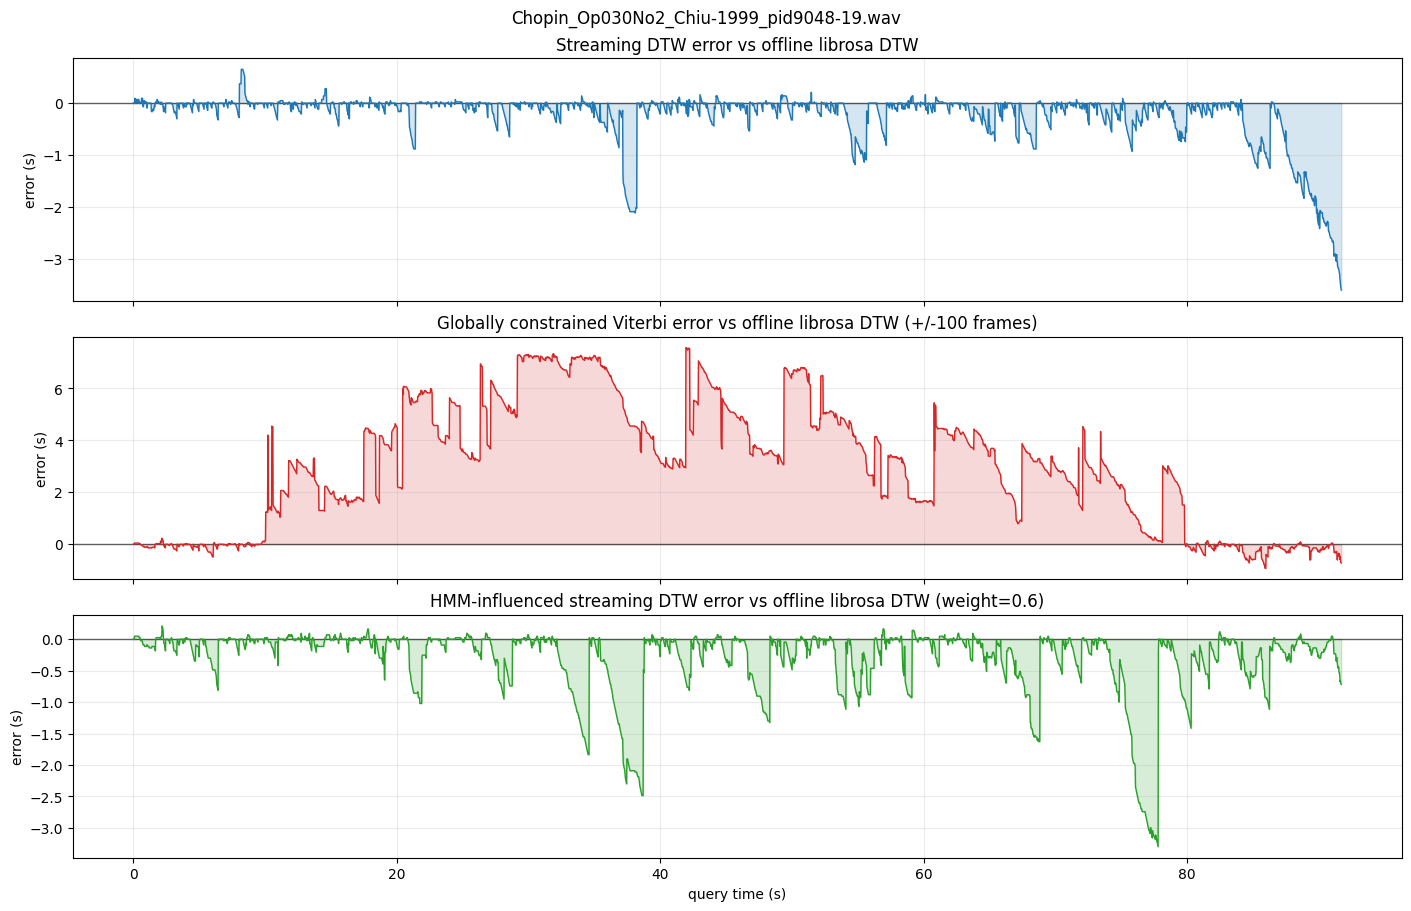

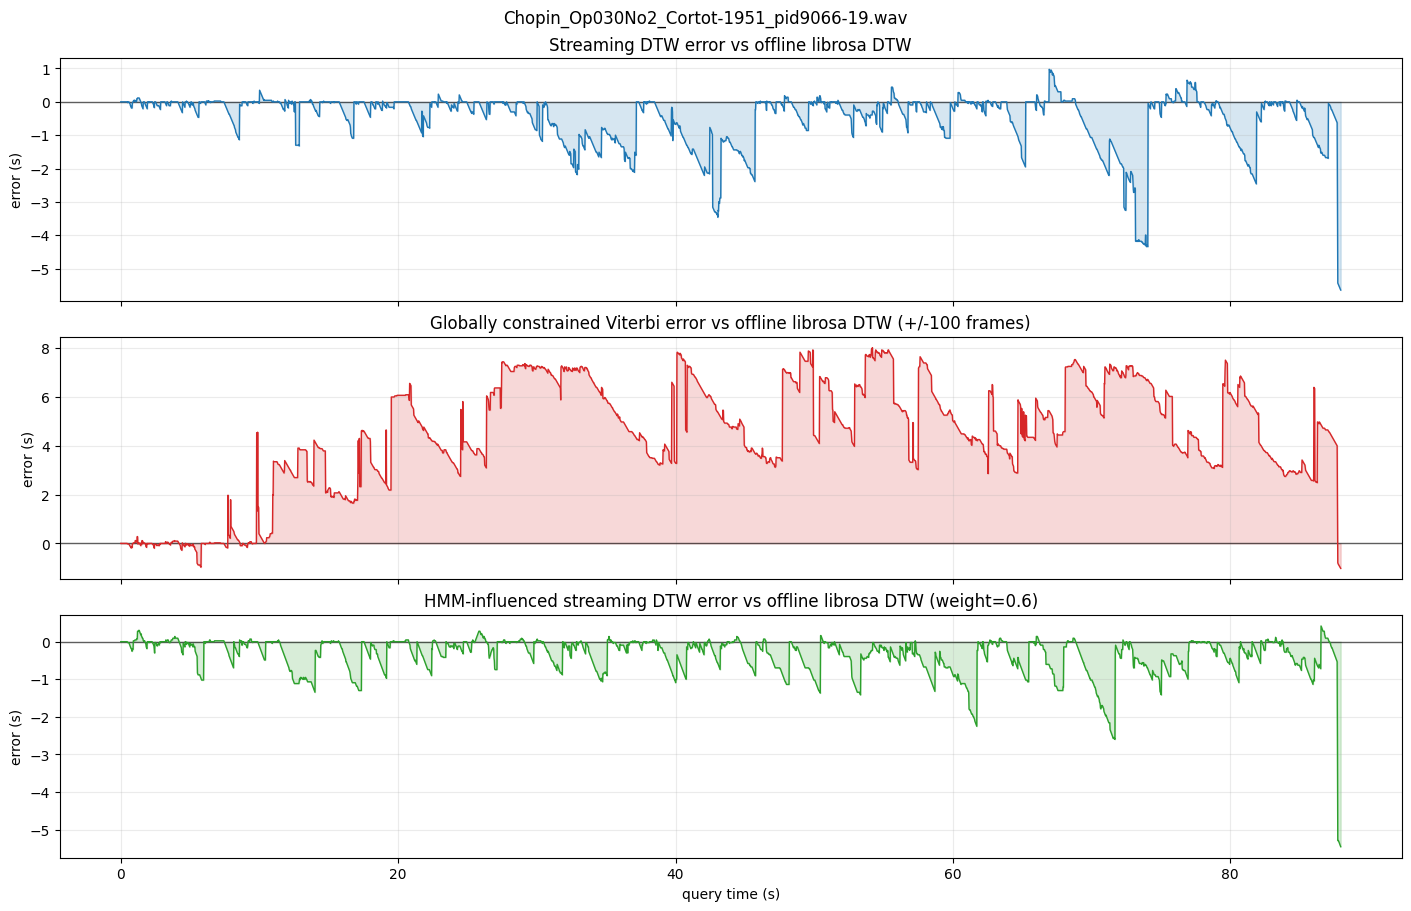

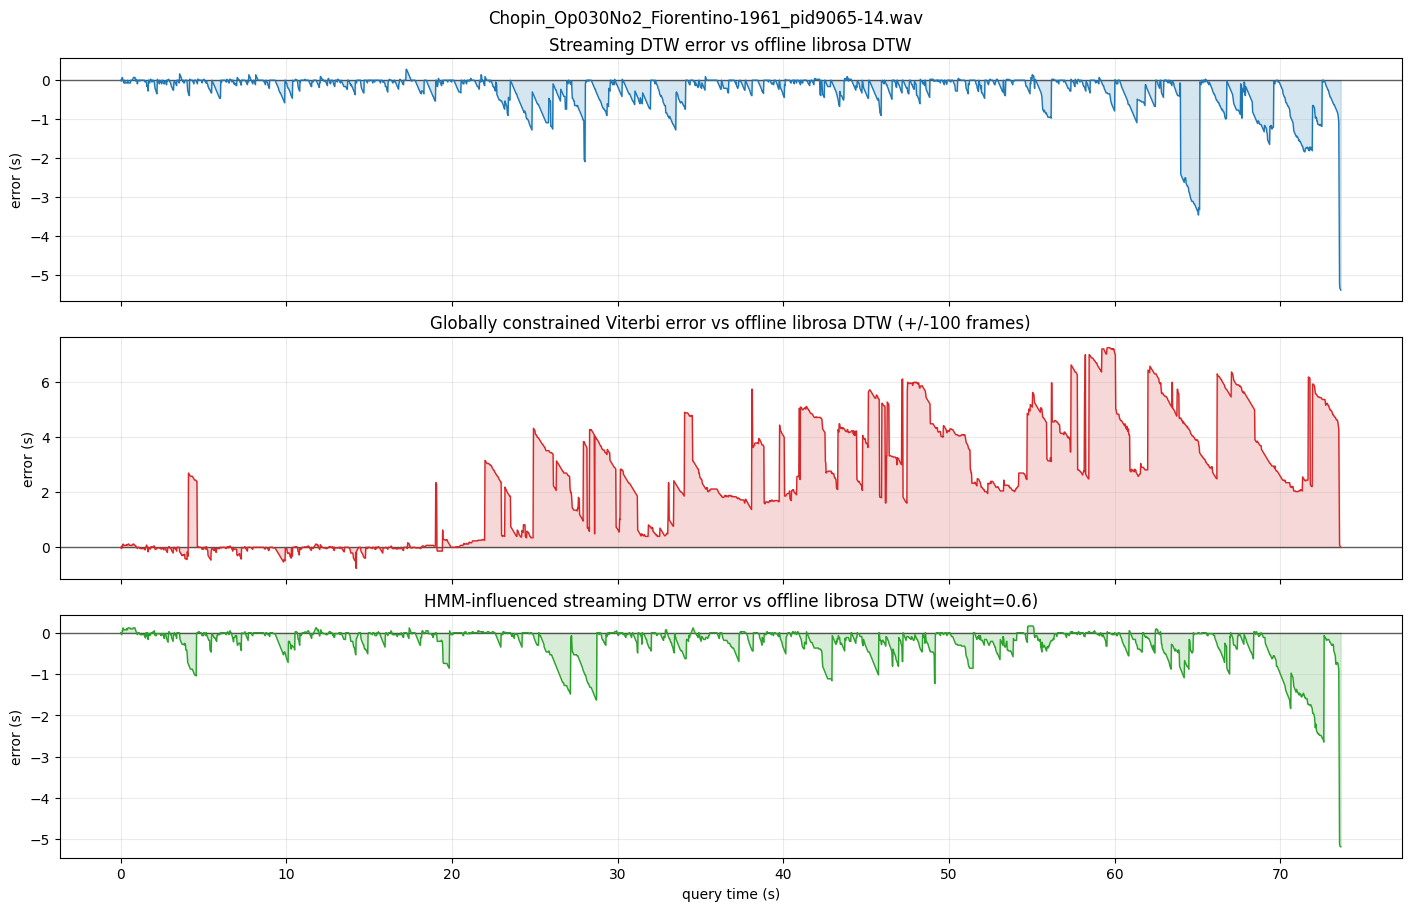

In [235]:
import matplotlib.pyplot as plt

for result in results:
    query_time = result["query_time"]
    offline_reference_by_query = result["offline_reference_by_query"]
    streaming_dtw_error_seconds = (
        result["streaming_dtw_reference_by_query"] - offline_reference_by_query
    ) * Constants.DEFAULT_HOP_SIZE_SAMPLES / sample_rate
    viterbi_error_seconds = (
        result["viterbi_reference_by_query"] - offline_reference_by_query
    ) * Constants.DEFAULT_HOP_SIZE_SAMPLES / sample_rate
    hmm_streaming_dtw_error_seconds = (
        result["hmm_streaming_dtw_reference_by_query"] - offline_reference_by_query
    ) * Constants.DEFAULT_HOP_SIZE_SAMPLES / sample_rate

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, constrained_layout=True)

    axes[0].axhline(0, color="black", linewidth=1, alpha=0.6)
    axes[0].plot(query_time, streaming_dtw_error_seconds, color="tab:blue", linewidth=1)
    axes[0].fill_between(query_time, 0, streaming_dtw_error_seconds, color="tab:blue", alpha=0.18)
    axes[0].set_ylabel("error (s)")
    axes[0].set_title("Streaming DTW error vs offline librosa DTW")
    axes[0].grid(alpha=0.25)

    axes[1].axhline(0, color="black", linewidth=1, alpha=0.6)
    axes[1].plot(query_time, viterbi_error_seconds, color="tab:red", linewidth=1)
    axes[1].fill_between(query_time, 0, viterbi_error_seconds, color="tab:red", alpha=0.18)
    axes[1].set_ylabel("error (s)")
    axes[1].set_title(f"Globally constrained Viterbi error vs offline librosa DTW (+/-{VITERBI_GLOBAL_HALF_WIDTH} frames)")
    axes[1].grid(alpha=0.25)

    axes[2].axhline(0, color="black", linewidth=1, alpha=0.6)
    axes[2].plot(query_time, hmm_streaming_dtw_error_seconds, color="tab:green", linewidth=1)
    axes[2].fill_between(query_time, 0, hmm_streaming_dtw_error_seconds, color="tab:green", alpha=0.18)
    axes[2].set_xlabel("query time (s)")
    axes[2].set_ylabel("error (s)")
    axes[2].set_title(f"HMM-influenced streaming DTW error vs offline librosa DTW (weight={HMM_STREAMING_DTW_WEIGHT})")
    axes[2].grid(alpha=0.25)

    fig.suptitle(result["query_path"].name)
    plt.show()

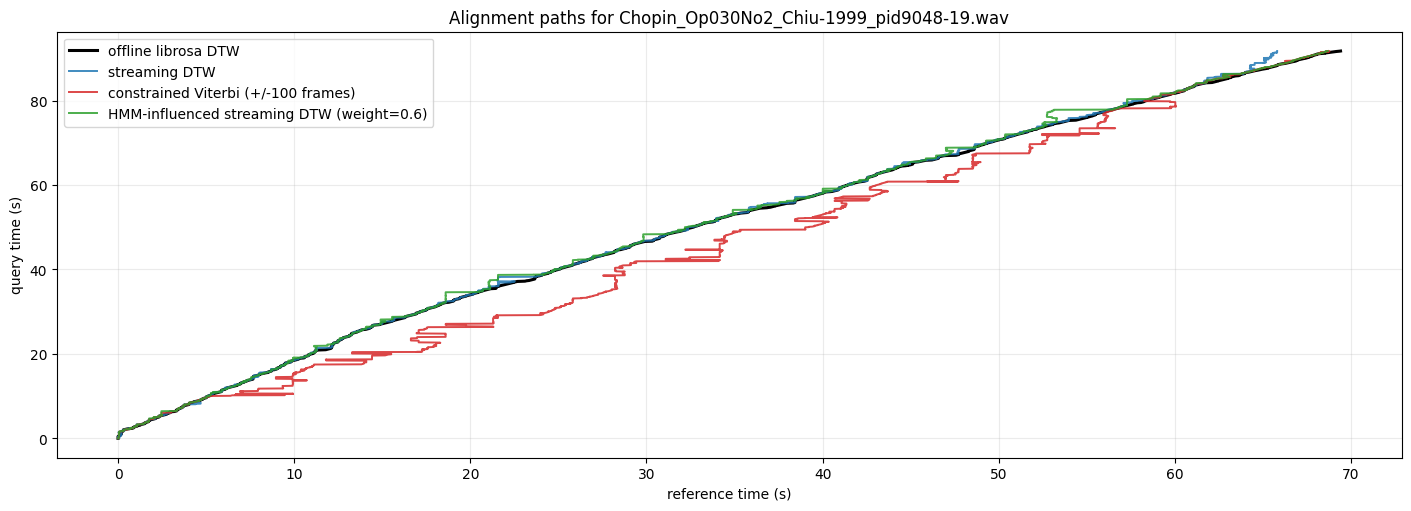

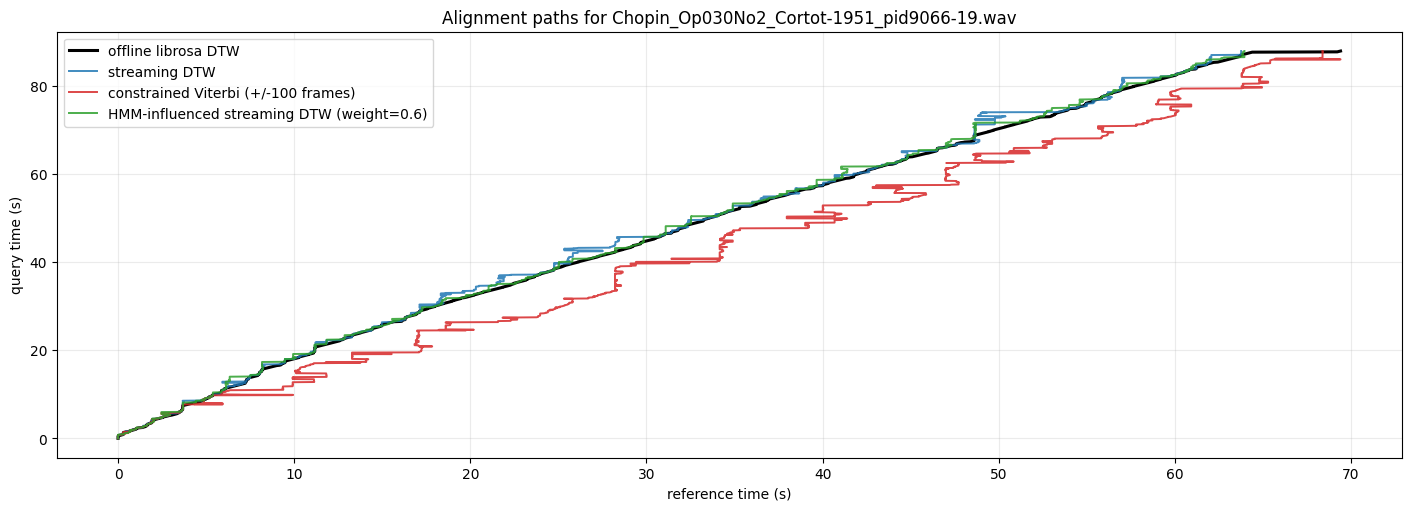

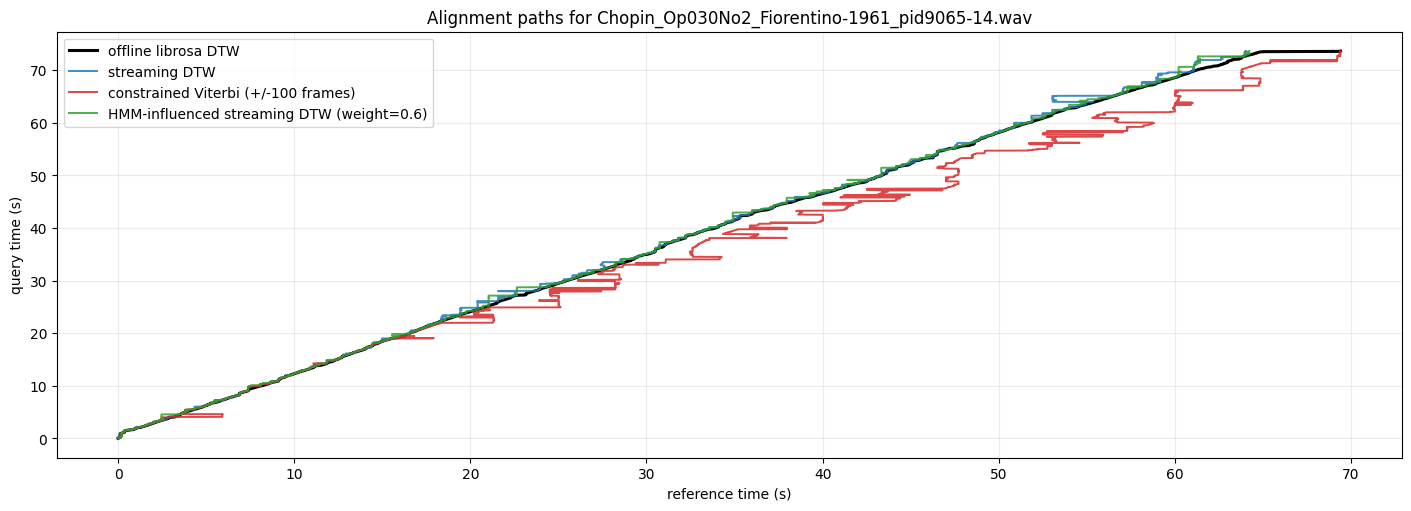

In [236]:
for result in results:
    query_time = result["query_time"]
    reference_time_offline = librosa.frames_to_time(
        result["offline_reference_by_query"],
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )
    reference_time_streaming_dtw = librosa.frames_to_time(
        result["streaming_dtw_reference_by_query"],
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )
    reference_time_viterbi = librosa.frames_to_time(
        result["viterbi_reference_by_query"],
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )
    reference_time_hmm_streaming_dtw = librosa.frames_to_time(
        result["hmm_streaming_dtw_reference_by_query"],
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )

    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
    ax.plot(reference_time_offline, query_time, label="offline librosa DTW", linewidth=2.2, color="black")
    ax.plot(reference_time_streaming_dtw, query_time, label="streaming DTW", linewidth=1.4, alpha=0.85, color="tab:blue")
    ax.plot(reference_time_viterbi, query_time, label=f"constrained Viterbi (+/-{VITERBI_GLOBAL_HALF_WIDTH} frames)", linewidth=1.4, alpha=0.85, color="tab:red")
    ax.plot(reference_time_hmm_streaming_dtw, query_time, label=f"HMM-influenced streaming DTW (weight={HMM_STREAMING_DTW_WEIGHT})", linewidth=1.4, alpha=0.85, color="tab:green")
    ax.set_ylabel("query time (s)")
    ax.set_xlabel("reference time (s)")
    ax.set_title(f"Alignment paths for {result['query_path'].name}")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.show()

## Mean Absolute Error Summary

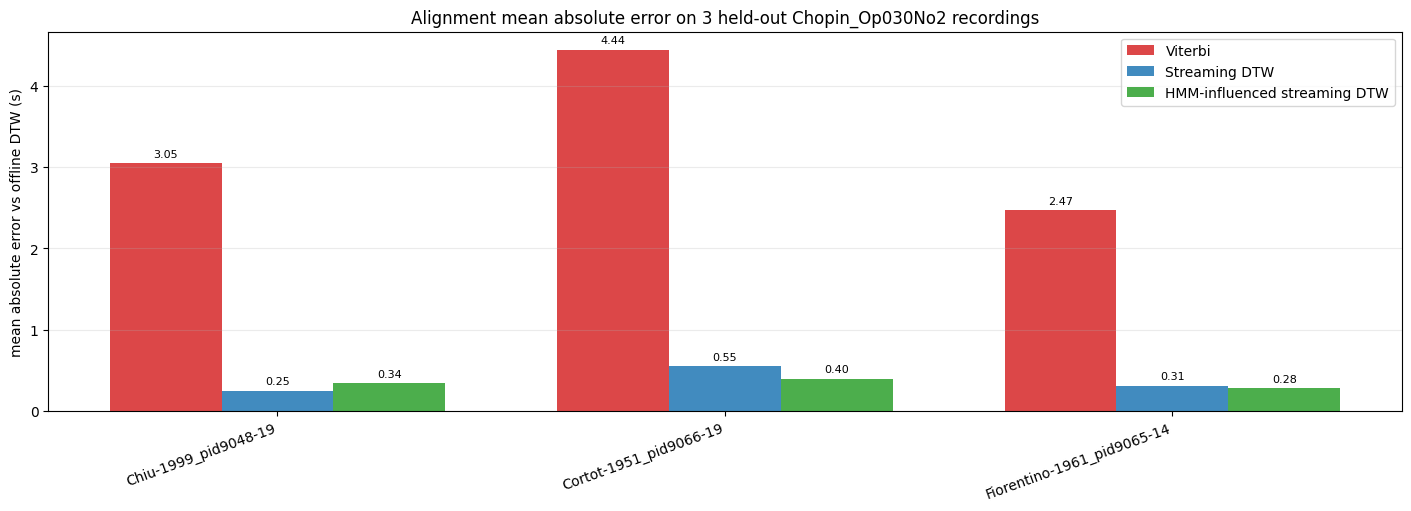

In [237]:
import matplotlib.pyplot as plt

methods = ["Viterbi", "Streaming DTW", "HMM-influenced streaming DTW"]
recording_labels = [result["recording"].replace(f"{PIECE_ID}_", "") for result in results]
mae_matrix = np.array([[result[method] for method in methods] for result in results])

x = np.arange(len(recording_labels))
bar_width = 0.25
colors = ["tab:red", "tab:blue", "tab:green"]

fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
for method_index, (method, color) in enumerate(zip(methods, colors)):
    offset = (method_index - 1) * bar_width
    bars = ax.bar(x + offset, mae_matrix[:, method_index], width=bar_width, label=method, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(recording_labels, rotation=20, ha="right")
ax.set_ylabel("mean absolute error vs offline DTW (s)")
ax.set_title(f"Alignment mean absolute error on {TEST_RECORDING_COUNT} held-out {PIECE_ID} recordings")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.show()